In [1]:
folder_name = "4160_px_same_width_noise_seeded" 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
import matplotlib.ticker as ticker
import os
import math
from scipy.special import erf

#for each of linear, erf, super erf, want:
#one array for each of ideal and realistic at each c (so 12 total, 1 for each SLM type)


##these are for generating the dip plots further down
Ls = [0, 10000, 50000, 100000, 150000, 200000]
titles = [f'L = {Ls[0]}', f'L = {Ls[1]}', f'L = {Ls[2]}', f'L = {Ls[3]}', f'L = {Ls[4]}', f'L = {Ls[5]}']


os.makedirs(f"results/{folder_name}/plots", exist_ok=True)

f = open(f"./results/{folder_name}/plotting_params.txt", "r")
params = f.readlines()
f.close()

dispersion_type = params[0].rstrip()
tau_range = int(params[1])
max_L = int(params[2])
L_stepsize = int(params[3])
bit_levels = int(params[4])
num_pixels = int(params[5])
max_lin_chirp = float(params[6])
max_erf_chirp = float(params[7])
max_superf_chirp = float(params[8])

gaussian_noises = [0,10,20,30,40]
binned_noises = [0,1,2,4,6]

Lvals = np.arange(0, max_L, L_stepsize)
taus = np.arange(-tau_range, tau_range + 0.5, 0.5)

# --- Initial guesses ---
init_guess = [0, 0.0025, 0.9, 10]

def one_minus_gaussian(t, t_0, a1, a2, fwhm):
    return a1 - a2*np.exp(-4*np.log(2)*((t - t_0)**2)/fwhm**2)

def chisq(params, t, y):
    t0, a1, a2, fwhm = params
    model = one_minus_gaussian(t, t0, a1, a2, fwhm)
    return np.sum((y - model)**2)

def residuals(params, t, y):
    T0, a1, a2, sigma = params
    model = (a1 - a2 * np.exp(-4 * np.log(2) * (t - T0)**2 / sigma**2))
    return model - y


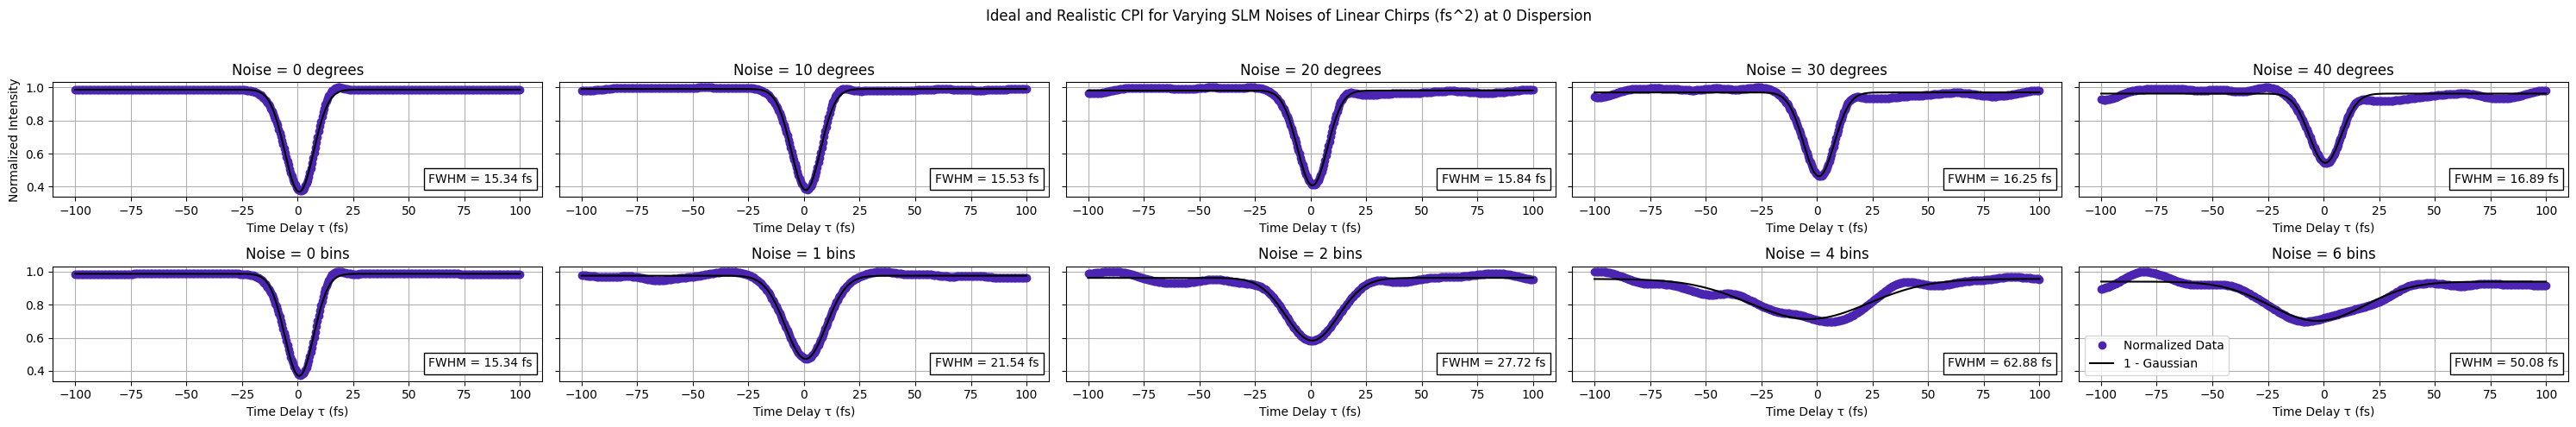

In [3]:
signals = []
curve_fits = []
params = []


fit_names= []
gauss_names = [f"Noise = {gaussian_noises[0]} degrees", f"Noise = {gaussian_noises[1]} degrees", 
               f"Noise = {gaussian_noises[2]} degrees",f"Noise = {gaussian_noises[3]} degrees", 
               f"Noise = {gaussian_noises[4]} degrees"]
bin_names = [f"Noise = {binned_noises[0]} bins", f"Noise = {binned_noises[1]} bins", 
               f"Noise = {binned_noises[2]} bins",f"Noise = {binned_noises[3]} bins", 
               f"Noise = {binned_noises[4]} bins"]
total_names = []
fwhms = []

for noise, name in zip(gaussian_noises, gauss_names):

    i_1 = np.loadtxt(f"./results/{folder_name}/linear/gaussian_noise/{noise}/L16000.txt")
    signals.append(i_1/np.max(i_1))

    # --- Initial guesses ---
    init_guess = [0.0, 0.0025, 0.9, 10.0]  # Corrected to 3 parameters

    # --- Fit the data ---
    result = least_squares(residuals, init_guess, args=(taus, i_1), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15)

    # Extract the parameters
    params.append(result.x)

    # Calculate the final chi-squared values
    final_chisq = result.cost

    # Print the fit parameters and chi-squared values
    #print(f"Fit Parameters (t0, a1, a2, fwhm) for {name}: {result.x}")
    #print(f"Final Chi-Squared Value for {name}: {final_chisq}")
    fwhms.append(result.x[3])
    
    # Evaluate the fits
    curve = one_minus_gaussian(taus, *result.x)
    curve_fits.append(curve/np.max(i_1))
    fit_names.append("1 - Gaussian")
    total_names.append(name)

for noise, name in zip(binned_noises, bin_names):

    r_1 = np.loadtxt(f"./results/{folder_name}/linear/binned_noise/{noise}/L16000.txt")
    signals.append(r_1/np.max(r_1))

    # --- Initial guesses ---
    init_guess = [0.0, 0.0025, 0.9, 10.0]  # Corrected to 3 parameters

    # --- Fit the data ---
    result = least_squares(residuals, init_guess, args=(taus, r_1), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15)

    # Extract the parameters
    params.append(result.x)

    # Calculate the final chi-squared values
    final_chisq = result.cost

    # Print the fit parameters and chi-squared values
    #print(f"Fit Parameters (t0, a1, a2, fwhm) for {name}: {result.x}")
    #print(f"Final Chi-Squared Value for {name}: {final_chisq}")
    fwhms.append(result.x[3])

    # Evaluate the fits
    curve = one_minus_gaussian(taus, *result.x)
    curve_fits.append(curve/np.max(r_1))
    fit_names.append("1 - Gaussian")
    total_names.append(name)


# --- Create subplots ---
fig, axes = plt.subplots(2, 5, figsize=(30, 5), sharey=True)

axes = axes.flatten()

for ax, signal, curve, name, fit, fwhm in zip(axes, signals, curve_fits, total_names, fit_names, fwhms):
    ax.plot(taus, signal, 'o', label='Normalized Data', color='#4B25B1')
    ax.plot(taus, curve, '-', label=fit, color='black')
    ax.set_xlabel('Time Delay τ (fs)')
    ax.text(
    0.98, 0.1, f'FWHM = {fwhm:.2f} fs',
    transform=ax.transAxes,  # <- use axes coords (0..1)
    ha='right', va='bottom',
    bbox=dict(facecolor='white', alpha=1)
    )
    ax.set_title(name)
    ax.grid(True)

    # --- Optional: print fitted parameters ---
    #print(f"Fitted parameters for {name}: a = {param[0]:.4f}, t0 = {param[1]:.4f} fs, FWHM = {param[2]:.4f} fs")
    
axes[0].set_ylabel('Normalized Intensity')
plt.suptitle(f"Ideal and Realistic CPI for Varying SLM Noises of Linear Chirps (fs^2) at 0 Dispersion")
plt.tight_layout(rect=[0, 0, 1, 0.95])  # second
plt.legend()
plt.savefig(f"results/{folder_name}/plots/linear_noise_dip_fits.png", bbox_inches='tight')
plt.show();


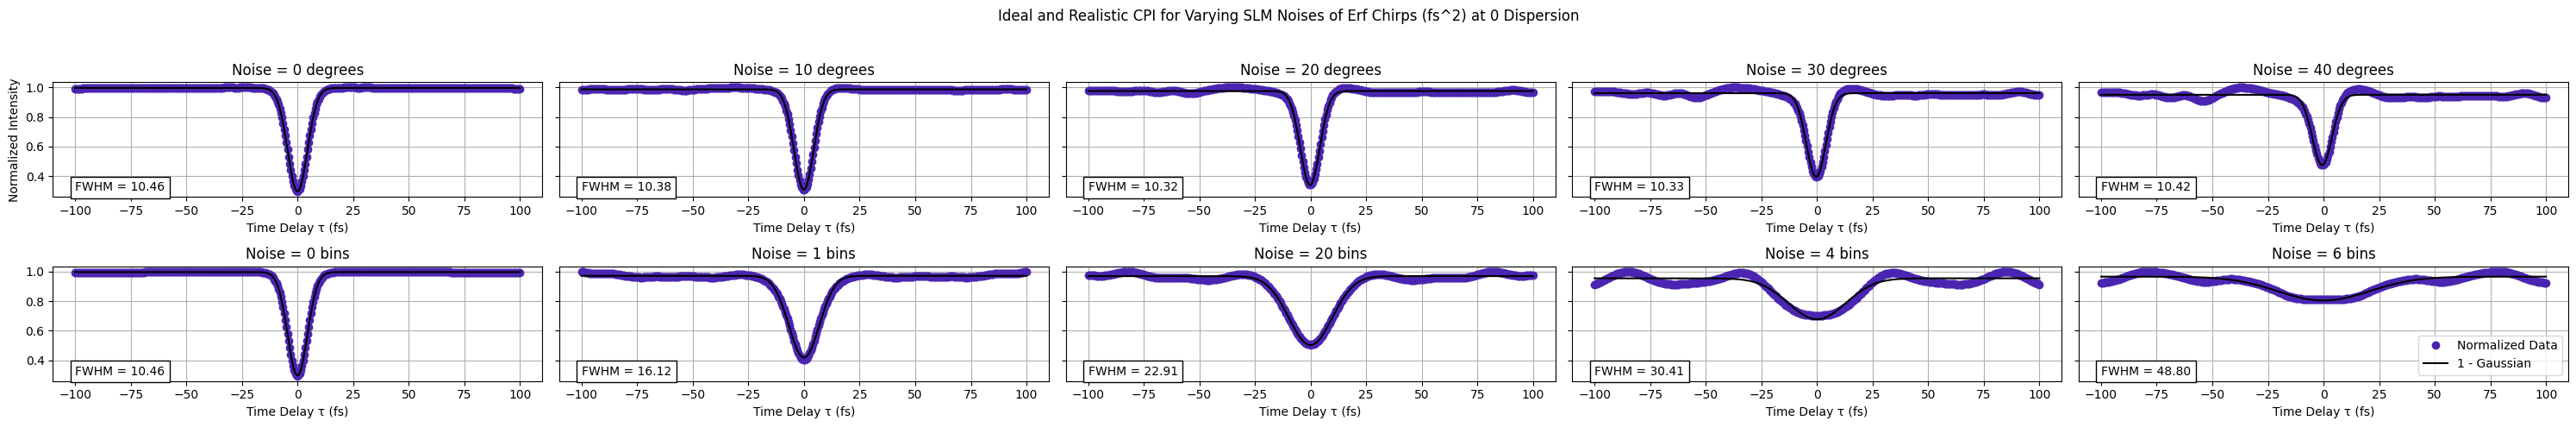

In [4]:
signals = []
curve_fits = []
params = []


fit_names= []
gauss_names = [f"Noise = {gaussian_noises[0]} degrees", f"Noise = {gaussian_noises[1]} degrees", 
               f"Noise = {gaussian_noises[2]} degrees",f"Noise = {gaussian_noises[3]} degrees", 
               f"Noise = {gaussian_noises[4]} degrees"]
bin_names = [f"Noise = {binned_noises[0]} bins", f"Noise = {binned_noises[1]} bins", 
               f"Noise = {gaussian_noises[2]} bins",f"Noise = {binned_noises[3]} bins", 
               f"Noise = {binned_noises[4]} bins"]
total_names = []
fwhms = []

for noise, name in zip(gaussian_noises, gauss_names):

    i_1 = np.loadtxt(f"./results/{folder_name}/erf/gaussian_noise/{noise}/L0.txt")
    signals.append(i_1/np.max(i_1))

    # --- Initial guesses ---
    init_guess = [0.0, 0.0025, 0.9, 10.0]  # Corrected to 3 parameters

    # --- Fit the data ---
    result = least_squares(residuals, init_guess, args=(taus, i_1), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15)

    # Extract the parameters
    params.append(result.x)

    # Calculate the final chi-squared values
    final_chisq = result.cost

    # Print the fit parameters and chi-squared values
    #print(f"Fit Parameters (t0, a1, a2, fwhm) for {name}: {result.x}")
    #print(f"Final Chi-Squared Value for {name}: {final_chisq}")
    fwhms.append(result.x[3])
    
    # Evaluate the fits
    curve = one_minus_gaussian(taus, *result.x)
    curve_fits.append(curve/np.max(i_1))
    fit_names.append("1 - Gaussian")
    total_names.append(name)

for noise, name in zip(binned_noises, bin_names):

    r_1 = np.loadtxt(f"./results/{folder_name}/erf/binned_noise/{noise}/L0.txt")
    signals.append(r_1/np.max(r_1))

    # --- Initial guesses ---
    init_guess = [0.0, 0.0025, 0.9, 10.0]  # Corrected to 3 parameters

    # --- Fit the data ---
    result = least_squares(residuals, init_guess, args=(taus, r_1), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15)

    # Extract the parameters
    params.append(result.x)

    # Calculate the final chi-squared values
    final_chisq = result.cost

    # Print the fit parameters and chi-squared values
    #print(f"Fit Parameters (t0, a1, a2, fwhm) for {name}: {result.x}")
    #print(f"Final Chi-Squared Value for {name}: {final_chisq}")
    fwhms.append(result.x[3])

    # Evaluate the fits
    curve = one_minus_gaussian(taus, *result.x)
    curve_fits.append(curve/np.max(r_1))
    fit_names.append("1 - Gaussian")
    total_names.append(name)


# --- Create subplots ---
fig, axes = plt.subplots(2, 5, figsize=(30, 5), sharey=True)

axes = axes.flatten()

for ax, signal, curve, name, fit, fwhm in zip(axes, signals, curve_fits, total_names, fit_names, fwhms):
    ax.plot(taus, signal, 'o', label='Normalized Data', color='#4B25B1')
    ax.plot(taus, curve, '-', label=fit, color='black')
    ax.set_xlabel('Time Delay τ (fs)')
    ax.text(-100, 0.3, f'FWHM = {fwhm:.2f}', bbox=dict(facecolor='white', alpha=1))
    ax.set_title(name)
    ax.grid(True)

    # --- Optional: print fitted parameters ---
    #print(f"Fitted parameters for {name}: a = {param[0]:.4f}, t0 = {param[1]:.4f} fs, FWHM = {param[2]:.4f} fs")
    
axes[0].set_ylabel('Normalized Intensity')
plt.suptitle(f"Ideal and Realistic CPI for Varying SLM Noises of Erf Chirps (fs^2) at 0 Dispersion")
plt.tight_layout(rect=[0, 0, 1, 0.95])  # second
plt.legend()
plt.savefig(f"results/{folder_name}/plots/erf_noise_dip_fits.png", bbox_inches='tight')
plt.show();


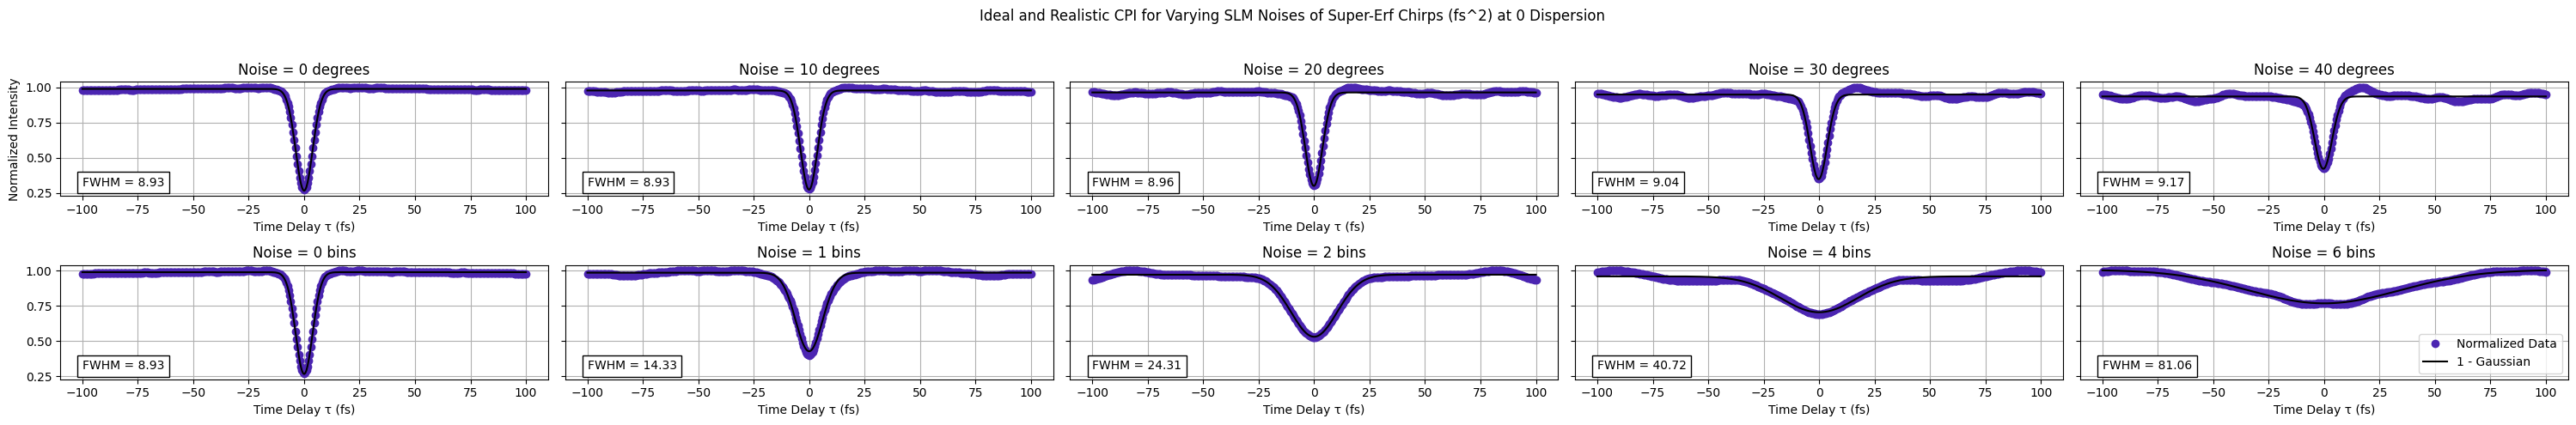

In [5]:
signals = []
curve_fits = []
params = []


fit_names= []
gauss_names = [f"Noise = {gaussian_noises[0]} degrees", f"Noise = {gaussian_noises[1]} degrees", 
               f"Noise = {gaussian_noises[2]} degrees",f"Noise = {gaussian_noises[3]} degrees", 
               f"Noise = {gaussian_noises[4]} degrees"]
bin_names = [f"Noise = {binned_noises[0]} bins", f"Noise = {binned_noises[1]} bins", 
               f"Noise = {binned_noises[2]} bins",f"Noise = {binned_noises[3]} bins", 
               f"Noise = {binned_noises[4]} bins"]
total_names = []
fwhms = []

for noise, name in zip(gaussian_noises, gauss_names):

    i_1 = np.loadtxt(f"./results/{folder_name}/super_erf/gaussian_noise/{noise}/L0.txt")
    signals.append(i_1/np.max(i_1))

    # --- Initial guesses ---
    init_guess = [0.0, 0.0025, 0.9, 10.0]  # Corrected to 3 parameters

    # --- Fit the data ---
    result = least_squares(residuals, init_guess, args=(taus, i_1), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15)

    # Extract the parameters
    params.append(result.x)

    # Calculate the final chi-squared values
    final_chisq = result.cost

    # Print the fit parameters and chi-squared values
    #print(f"Fit Parameters (t0, a1, a2, fwhm) for {name}: {result.x}")
    #print(f"Final Chi-Squared Value for {name}: {final_chisq}")
    fwhms.append(result.x[3])
    
    # Evaluate the fits
    curve = one_minus_gaussian(taus, *result.x)
    curve_fits.append(curve/np.max(i_1))
    fit_names.append("1 - Gaussian")
    total_names.append(name)

for noise, name in zip(binned_noises, bin_names):

    r_1 = np.loadtxt(f"./results/{folder_name}/super_erf/binned_noise/{noise}/L0.txt")
    signals.append(r_1/np.max(r_1))

    # --- Initial guesses ---
    init_guess = [0.0, 0.0025, 0.9, 10.0]  # Corrected to 3 parameters

    # --- Fit the data ---
    result = least_squares(residuals, init_guess, args=(taus, r_1), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15)

    # Extract the parameters
    params.append(result.x)

    # Calculate the final chi-squared values
    final_chisq = result.cost

    # Print the fit parameters and chi-squared values
    #print(f"Fit Parameters (t0, a1, a2, fwhm) for {name}: {result.x}")
    #print(f"Final Chi-Squared Value for {name}: {final_chisq}")
    fwhms.append(result.x[3])

    # Evaluate the fits
    curve = one_minus_gaussian(taus, *result.x)
    curve_fits.append(curve/np.max(r_1))
    fit_names.append("1 - Gaussian")
    total_names.append(name)


# --- Create subplots ---
fig, axes = plt.subplots(2, 5, figsize=(30, 5), sharey=True)

axes = axes.flatten()

for ax, signal, curve, name, fit, fwhm in zip(axes, signals, curve_fits, total_names, fit_names, fwhms):
    ax.plot(taus, signal, 'o', label='Normalized Data', color='#4B25B1')
    ax.plot(taus, curve, '-', label=fit, color='black')
    ax.set_xlabel('Time Delay τ (fs)')
    ax.text(-100, 0.3, f'FWHM = {fwhm:.2f}', bbox=dict(facecolor='white', alpha=1))
    ax.set_title(name)
    ax.grid(True)

    # --- Optional: print fitted parameters ---
    #print(f"Fitted parameters for {name}: a = {param[0]:.4f}, t0 = {param[1]:.4f} fs, FWHM = {param[2]:.4f} fs")
    
axes[0].set_ylabel('Normalized Intensity')
plt.suptitle(f"Ideal and Realistic CPI for Varying SLM Noises of Super-Erf Chirps (fs^2) at 0 Dispersion")
plt.tight_layout(rect=[0, 0, 1, 0.95])  # second
plt.legend()
plt.savefig(f"results/{folder_name}/plots/superf_noise_dip_fits.png", bbox_inches='tight')
plt.show();


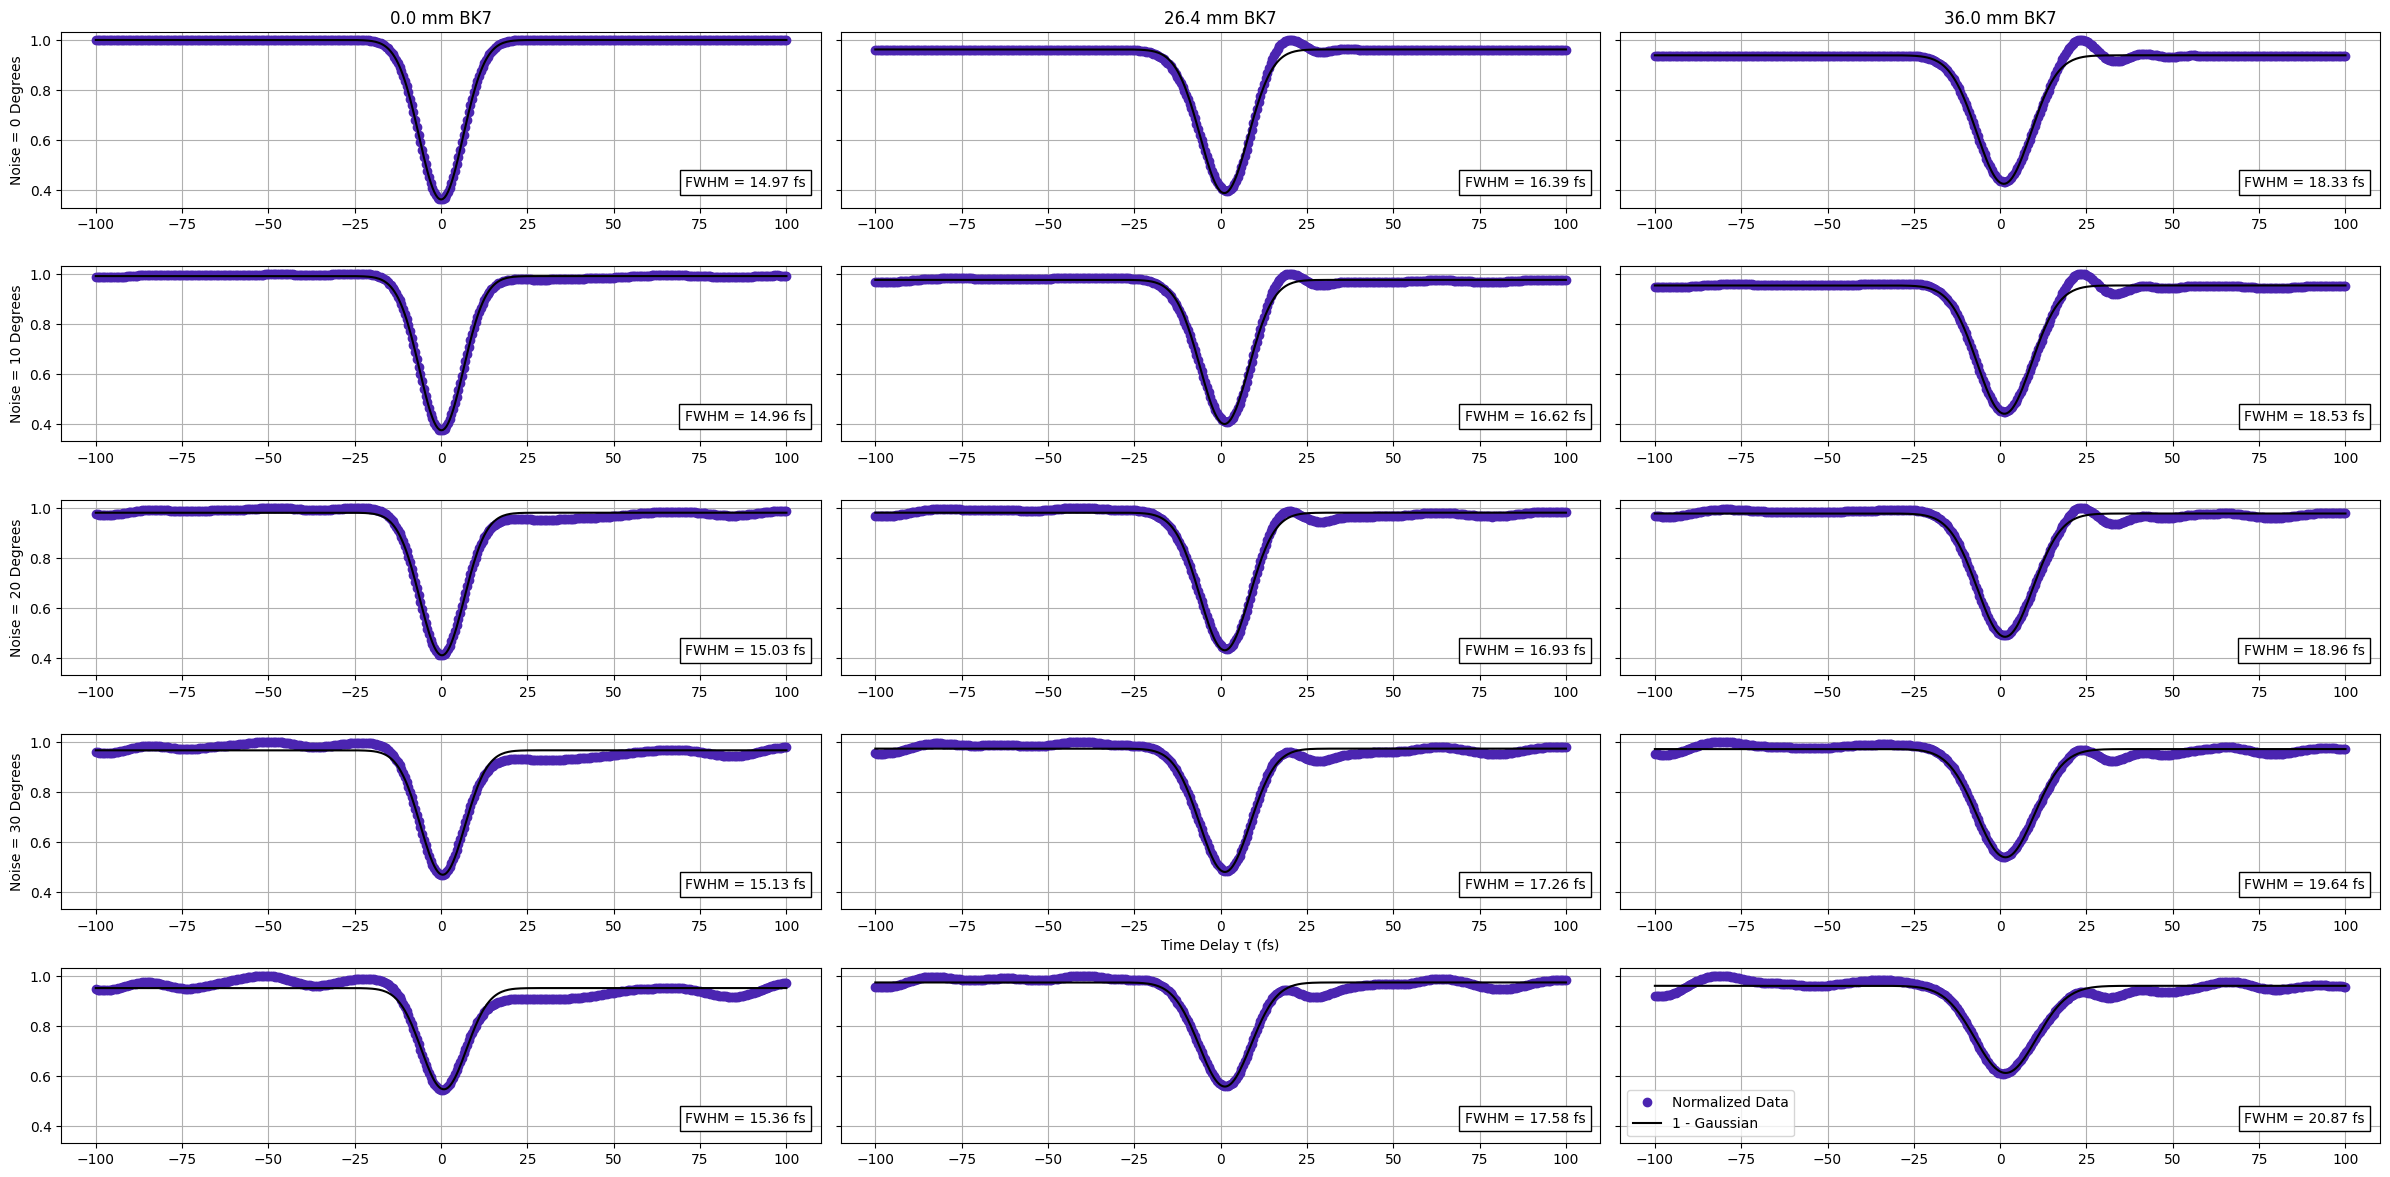

In [14]:
signals = []
curve_fits = []
params = []

dispersion_type = 'linear'

fit_names= []
gauss_names = [f"Noise = {gaussian_noises[0]} degrees", f"Noise = {gaussian_noises[1]} degrees", 
               f"Noise = {gaussian_noises[2]} degrees",f"Noise = {gaussian_noises[3]} degrees", 
               f"Noise = {gaussian_noises[4]} degrees"]
bin_names = [f"Noise = {binned_noises[0]} bins", f"Noise = {binned_noises[1]} bins", 
               f"Noise = {binned_noises[2]} bins",f"Noise = {binned_noises[3]} bins", 
               f"Noise = {binned_noises[4]} bins"]
total_names = []
fwhms = []

noises = [0, 10, 20, 30, 40]
Ls = [0, 26400, 36000]

for noise, name in zip(gaussian_noises, gauss_names):
    for L in Ls:
        i_1 = np.loadtxt(f"./results/{folder_name}/{dispersion_type}/gaussian_noise/{noise}/L{L}.txt")
        signals.append(i_1/np.max(i_1))

        # --- Initial guesses ---
        init_guess = [0.0, 0.0025, 0.9, 10.0]  # Corrected to 3 parameters

        # --- Fit the data ---
        result = least_squares(residuals, init_guess, args=(taus, i_1), method='lm', 
                                ftol=1e-15, xtol=1e-15, gtol=1e-15)

        # Extract the parameters
        params.append(result.x)

        # Calculate the final chi-squared values
        final_chisq = result.cost

        # Print the fit parameters and chi-squared values
        #print(f"Fit Parameters (t0, a1, a2, fwhm) for {name}: {result.x}")
        #print(f"Final Chi-Squared Value for {name}: {final_chisq}")
        fwhms.append(result.x[3])
        
        # Evaluate the fits
        curve = one_minus_gaussian(taus, *result.x)
        curve_fits.append(curve/np.max(i_1))
        fit_names.append("1 - Gaussian")
        total_names.append(name)


# --- Create subplots ---
fig, axes = plt.subplots(5, 3, figsize=(24, 12.5), sharey=True)

axes = axes.flatten()

for ax, signal, curve, name, fit, fwhm in zip(axes, signals, curve_fits, total_names, fit_names, fwhms):
    ax.plot(taus, signal, 'o', label='Normalized Data', color='#4B25B1')
    ax.plot(taus, curve, '-', label=fit, color='black')
    #ax.set_xlabel('Time Delay τ (fs)')
    ax.text(
    0.98, 0.1, f'FWHM = {fwhm:.2f} fs',
    transform=ax.transAxes,  # <- use axes coords (0..1)
    ha='right', va='bottom',
    bbox=dict(facecolor='white', alpha=1)
    )
    ax.grid(True)

    # --- Optional: print fitted parameters ---
    #print(f"Fitted parameters for {name}: a = {param[0]:.4f}, t0 = {param[1]:.4f} fs, FWHM = {param[2]:.4f} fs")
    
axes[0].set_ylabel('Normalized Intensity')
axes[0].set_title(f'{Ls[0]/1000} mm BK7')
axes[1].set_title(f'{Ls[1]/1000} mm BK7')
axes[2].set_title(f'{Ls[2]/1000} mm BK7')

axes[0].set_ylabel(f'Noise = {noises[0]} Degrees')
axes[3].set_ylabel(f'Noise = {noises[1]} Degrees')
axes[6].set_ylabel(f'Noise = {noises[2]} Degrees')
axes[9].set_ylabel(f'Noise = {noises[3]} Degrees')

axes[10].set_xlabel('Time Delay τ (fs)')
#plt.suptitle(f"Ideal and Realistic CPI for Varying SLM Noises of Linear Chirps (fs^2) at 0 Dispersion")
plt.tight_layout(rect=[0, 0, 1, 0.95])  # second
plt.legend()
plt.savefig(f"results/{folder_name}/plots/{dispersion_type}_noise_dip_fits_w_disp_{num_pixels}.png", bbox_inches='tight')
plt.show();
